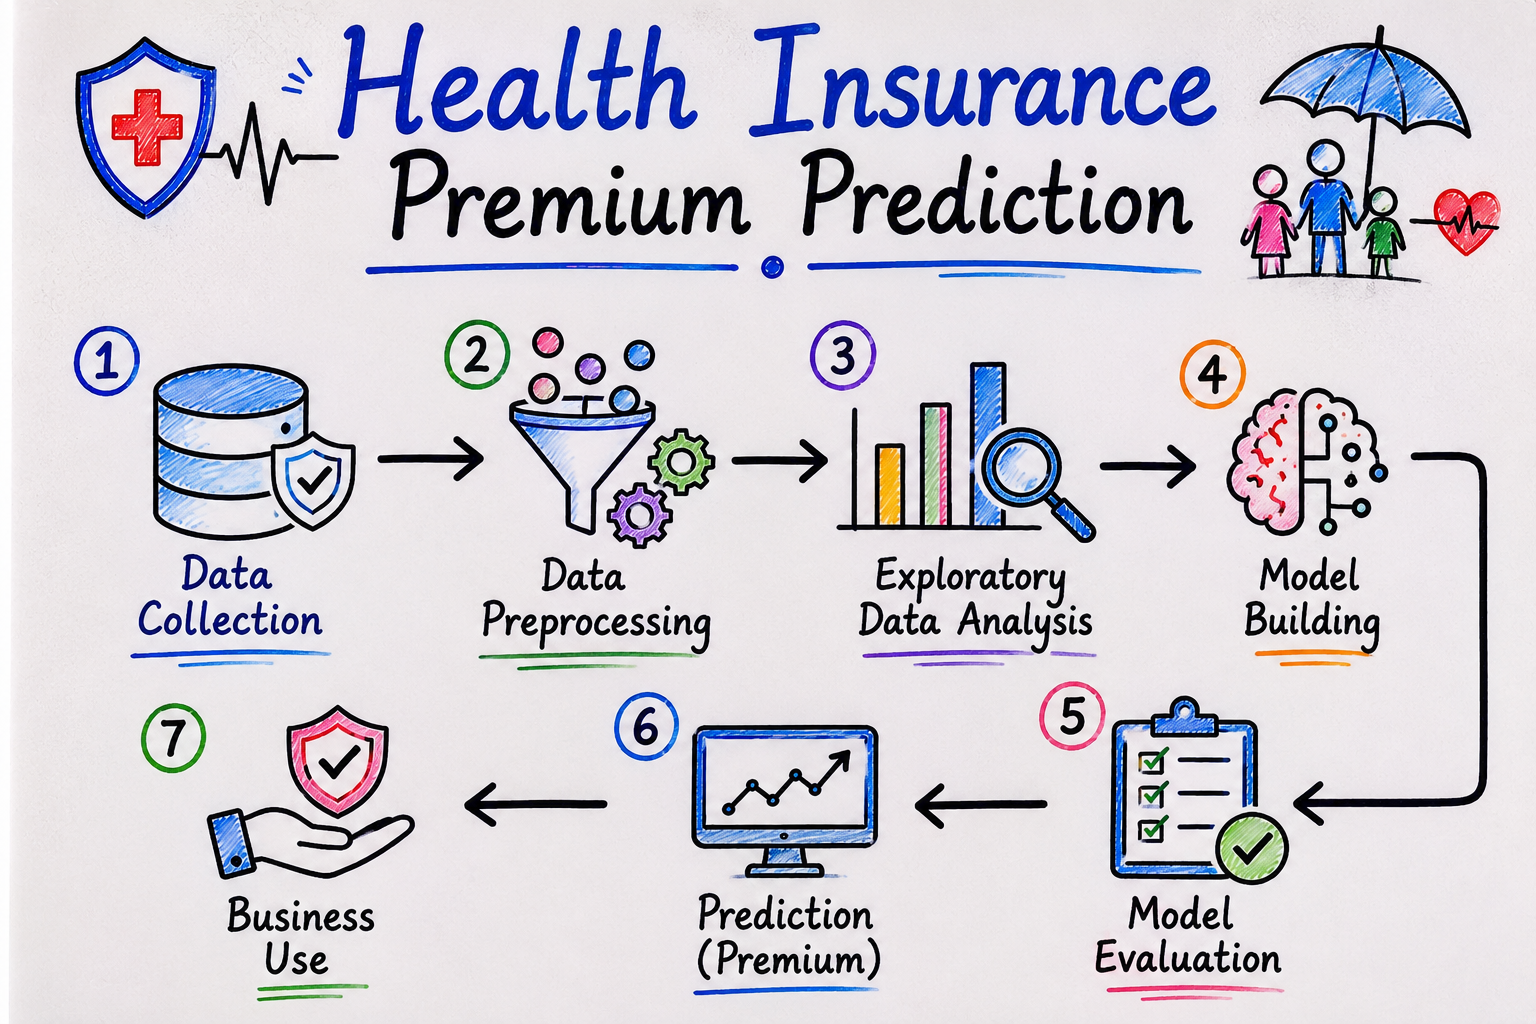

# **Problem Statement**

## **Business Context**

1. Healthcare costs are increasing every year.
2. Insurance companies need to decide the correct premium for each customer.
3. Charging too much may cause customers to leave.
4.  Charging too little may reduce company profit.
5.  Therefore, companies use Machine Learning to predict insurance charges accurately.






## **Objective**

The main objective is to build a Linear Regression model to predict health insurance charges using customer information.

**Input Features**

- Age
- Gender (Sex)
- BMI (Body Mass Index)
- Number of Children
- Smoking Status
- Region

##**Data Description**


The dataset consists of several key attributes:

- **Age**: Numerical value representing the age of the insured individual.
- **Sex**: Categorical variable indicating gender (male or female).
- **BMI**: Numerical value reflecting the Body Mass Index, a measure of body fat based on height and weight.
- **Children**: Numerical value representing the number of dependent children covered by the insurance policy.
- **Smoker**: Categorical variable indicating whether the individual is a smoker (yes or no).
- **Region**: Categorical variable that identifies the geographic area of the insured (southwest, southeast, northwest, northeast).
- **Charges**: Numerical value indicating the annual insurance premium (in USD) incurred by the policyholder.

This dataset contains a diverse range of cases, facilitating the modeling of different demographic and health profiles to predict insurance charges effectively.

In [ ]:
# uncomment and run the following line if using Google Colab
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# **Installing and Importing Necessary Libraries**



- **NumPy** – Performs numerical and mathematical operations.
- **Pandas** – Loads, cleans, and manipulates datasets.
- **Matplotlib** – Creates basic charts and graphs.
- **Seaborn** – Creates attractive statistical visualizations.
- **Scikit-learn (sklearn)** – Builds, trains, and evaluates machine learning models.

In [ ]:
# Import libraries for reading and manipulating data
import pandas as pd
# Import library for numerical operations
import numpy as np

# Import libraries for data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Import Linear Regression model
from sklearn.linear_model import LinearRegression

# Import utilities for performance evaluation
from sklearn.metrics import mean_squared_error, r2_score

# Import utilities for data preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# **Loading the Data**



- Load the **insurance_prediction.csv** dataset using the **Pandas** library.
- Store the dataset in a **DataFrame**.
- Verify that the dataset is loaded successfully.
- Display the first few rows using `head()`.
- Understand the dataset before preprocessing and analysis.




 **Load the insurance_prediction.csv file and store it as data.**


In [ ]:
data = pd.read_csv('/content/drive/MyDrive/GEN AI DATASET/insurance_prediction.csv')


- The CSV file can also be directly loaded from Google Drive.

**Load the insurance_prediction.csv file from Google Drive and store it as data.**


In [ ]:
#from google.colab import drive
#drive.mount('/content/drive')

# Load the dataset
#data = pd.read_csv('/content/drive/insurance_prediction.csv')


# **Data Overview**

Now that the dataset is loaded, it's important to understand its structure and content before diving into deeper analysis. This step involves:

- Checking the number of rows and columns.
- Viewing the first few records to get a sense of the data.
- Identifying data types for each feature.
- Detecting any potential missing values or anomalies.



**Display the number of rows and columns in the data.**


In [ ]:
data.shape

(1338, 7)

The dataset consists of 1,338 rows and 7 columns

 **Display the first 10 rows of the data.**


In [ ]:
print(data.head(10))


   age     sex     bmi  children smoker     region      charges
0   19  female  27.900         0    yes  southwest  16884.92400
1   18    male  33.770         1     no  southeast   1725.55230
2   28    male  33.000         3     no  southeast   4449.46200
3   33    male  22.705         0     no  northwest  21984.47061
4   32    male  28.880         0     no  northwest   3866.85520
5   31  female  25.740         0     no  southeast   3756.62160
6   46  female  33.440         1     no  southeast   8240.58960
7   37  female  27.740         3     no  northwest   7281.50560
8   37    male  29.830         2     no  northeast   6406.41070
9   60  female  25.840         0     no  northwest  28923.13692




- If the output is not displayed in a **table format**, remove the `print()` statement.
- Instead of using:

```python
print(df.head(10))

In [ ]:
data.head(10)

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
5,31,female,25.740,0,no,southeast,3756.62160
6,46,female,33.440,1,no,southeast,8240.58960
7,37,female,27.740,3,no,northwest,7281.50560
8,37,male,29.830,2,no,northeast,6406.41070
9,60,female,25.840,0,no,northwest,28923.13692


**Display the last 10 rows of the data.**


In [ ]:
data.tail(10)

,age,sex,bmi,children,smoker,region,charges
1328,23,female,24.225,2,no,northeast,22395.74424
1329,52,male,38.600,2,no,southwest,10325.20600
1330,57,female,25.740,2,no,southeast,12629.16560
1331,23,female,33.400,0,no,southwest,10795.93733
1332,52,female,44.700,3,no,southwest,11411.68500
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500
1337,61,female,29.070,0,yes,northwest,29141.36030


**Display the column names, data types, and number of rows in the data.**
</font>

The code provides a summary of the DataFrame, including the number of non-null entries, data types, and memory usage.


In [ ]:
data.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


- The dataset contains **7 columns** and **1338 rows**, with **no missing values**.
- Data types are as expected:  
  - **Numeric:** `age`, `bmi`, `children`, `charges`  
  - **Categorical:** `sex`, `smoker`, `region`

**Note:**  We conclude there are no missing rows in the DataFrame as all columns have 1338 non-null entries, matching the total number of records.

>**Display the statistical summary of the data**


In [ ]:
data.describe()


,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [ ]:
data.describe().T


,count,mean,std,min,25%,50%,75%,max
age,1338.0,39.207025,14.049960,18.0000,27.00000,39.000,51.000000,64.00000
bmi,1338.0,30.663397,6.098187,15.9600,26.29625,30.400,34.693750,53.13000
children,1338.0,1.094918,1.205493,0.0000,0.00000,1.000,2.000000,5.00000
charges,1338.0,13270.422265,12110.011237,1121.8739,4740.28715,9382.033,16639.912515,63770.42801




- To make the output easier to read, use **`.T` (transpose)**.
- `.T` converts **rows into columns** and **columns into rows**.
- This provides a cleaner and more readable view of the data.



**Observations:**
1. **Age:** The average age is **39.21 years**, with values ranging from **18 to 64**, indicating a broad adult age group.

2. **BMI:** The mean BMI is **30.66**, suggesting that the **average individual is classified as obese**.

3. **Children:** On average, individuals have **about 1 child**, with most having between **0 and 2 children**.

4. **Charges:** The **average medical charge is 13,270.42**, but the high standard deviation indicates **large variability** in healthcare costs.



The current summary displays only the numerical columns. Now, let’s move on to explore the summary of the categorical features.

**Display the summary of categorical variables.**


In [ ]:
data.describe(include='object')


,sex,smoker,region
count,1338,1338,1338
unique,2,2,4
top,male,no,southeast
freq,676,1064,364


1. **Gender:** The dataset has a nearly balanced gender distribution, with **male** being slightly more frequent (676 out of 1338).  
2. **Smoking Status:** **Non-smokers** dominate the dataset (1064 entries), which could impact charge predictions.  
3. **Region:** The **southeast** region has the highest number of entries (364), making it the most represented geographic area.

**How many duplicate rows are present in the data**


In [ ]:
# Identify duplicate rows
duplicate_rows = data[data.duplicated()]

In [ ]:
# Print the number of duplicate rows
print(f"Number of duplicate rows: {len(duplicate_rows)}")

Number of duplicate rows: 1


In [ ]:
# Display the duplicate rows (optional)
duplicate_rows


,age,sex,bmi,children,smoker,region,charges
581,19,male,30.59,0,no,northwest,1639.5631


 **Drop the duplicate rows.**


In [ ]:
# Drop duplicate rows
data = data.drop_duplicates()

# Print the shape of the DataFrame after removing duplicates
print(f"Shape after removing duplicates: {data.shape}")


Shape after removing duplicates: (1337, 7)


There were originally 1,338 rows. After removing 1 duplicate record, the dataset now contains 1,337 records.

# **Exploratory Data Analysis**


Exploratory Data Analysis (EDA) is used to understand the dataset before building a machine learning model.

**Purpose**

- Analyze numerical features such as **Age, BMI, and Charges**.
- Analyze categorical features such as **Sex, Smoker, Region, and Children**.
- Find relationships between variables.
- Identify patterns, trends, and outliers.
- Better understand the data before model training.




## **Univariate Analysis**

**Univariate Analysis examines a single variable to understand its distribution and characteristics.**

**Visualize the distribution of age in the data.**


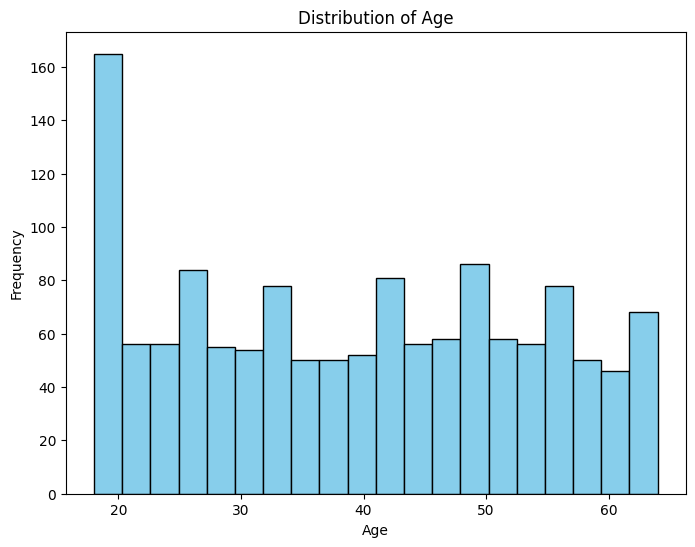

In [ ]:
plt.figure(figsize=(8, 6))
plt.hist(data['age'], bins=20, color='skyblue', edgecolor='black')
plt.title('Distribution of Age')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()


To understand the purpose of each line of code, we update the prompt by adding "Explain the code" for clarity on each task.

 **Visualize the distribution of age in the data and explain the code.**


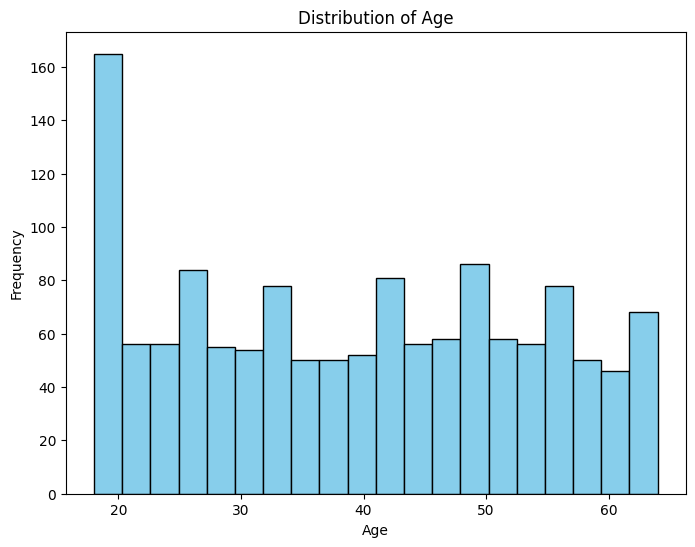

In [ ]:
# Create a histogram of the 'age' column
plt.figure(figsize=(8, 6))
plt.hist(data['age'], bins=20, color='skyblue', edgecolor='black')
plt.title('Distribution of Age')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()


 **Observation**

- Most customers are in the **20–25 years** age group.
- Younger individuals have a **higher count** in the dataset.
- This indicates that **young adults are more likely to have health insurance**.
- The number of customers **decreases as age increases**.

**Gender Distribution**

- Check the distribution of **Male** and **Female** in the dataset.
- Verify whether both genders are **equally represented**.
- A balanced dataset helps the model learn fairly.
- It reduces bias and improves prediction accuracy.


**Visualize the distribution of gender in the data.**


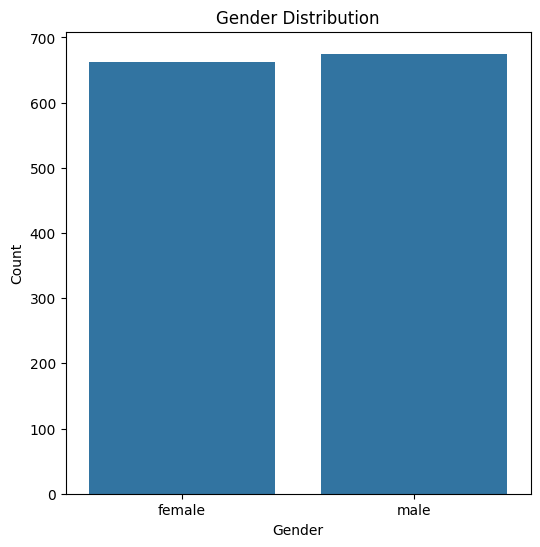

In [ ]:
# Check gender distribution to see if the data is balanced.
plt.figure(figsize=(6, 6))
sns.countplot(x='sex', data=data)
plt.title('Gender Distribution')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.show()


**Observation**:
Gender distribution is analyzed to ensure the dataset is balanced and free from gender bias.

**Visualize the distribution of BMI in the data.**


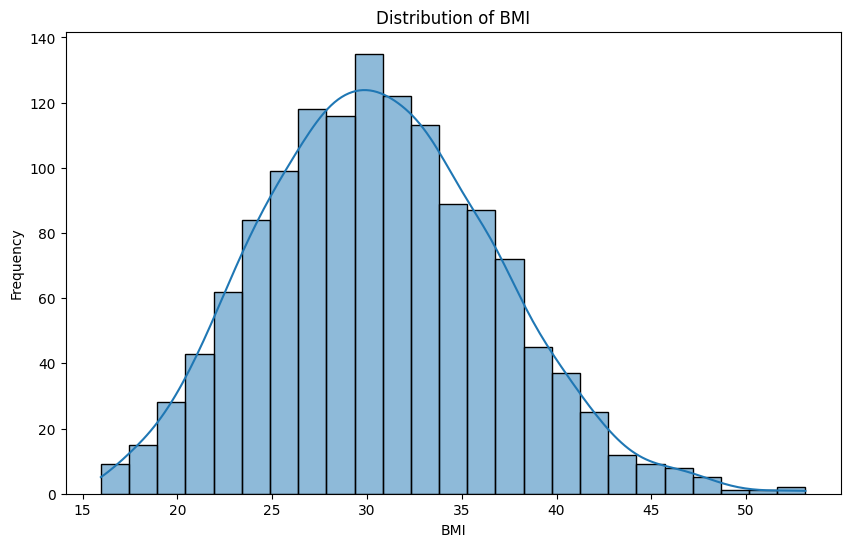

In [ ]:
# Analyze how BMI varies across individuals to detect obesity trends.
plt.figure(figsize=(10, 6))
sns.histplot(data['bmi'], kde=True)#Kernel Density Estimation.
plt.title('Distribution of BMI')
plt.xlabel('BMI')
plt.ylabel('Frequency')
plt.show()


**Observations:**
Most people have a BMI close to 30, with a few high BMI outliers above 45.


**NOTE**:

- Different charts can display the same data in different ways.
- A **Histogram** shows only the frequency of values.
- A **Histogram with KDE** shows both the frequency and a smooth distribution curve.
- To get the desired visualization, clearly specify the chart type in your prompt or code.



**Visualize the distribution of smokers in the data.**


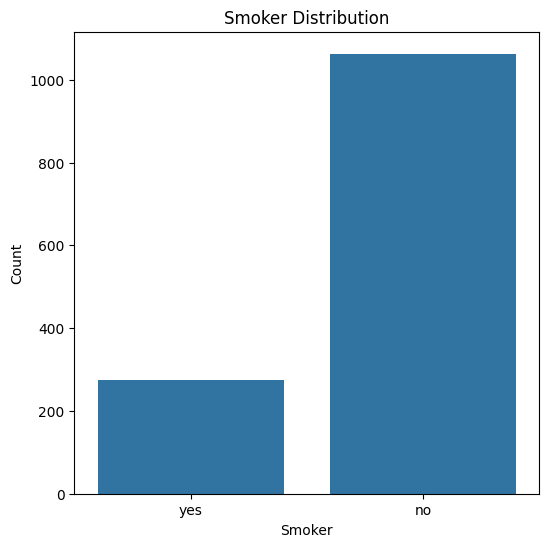

In [ ]:
# Visualize the distribution of smokers in the data.
plt.figure(figsize=(6, 6))
sns.countplot(x='smoker', data=data)
plt.title('Smoker Distribution')
plt.xlabel('Smoker')
plt.ylabel('Count')
plt.show()


**Observations:**
- The majority of the population appears to be non-smokers.
- This indicates that smoking status could be a key factor in health insurance assessments.

**Visualize the distribution of regions in the data.**
</font>

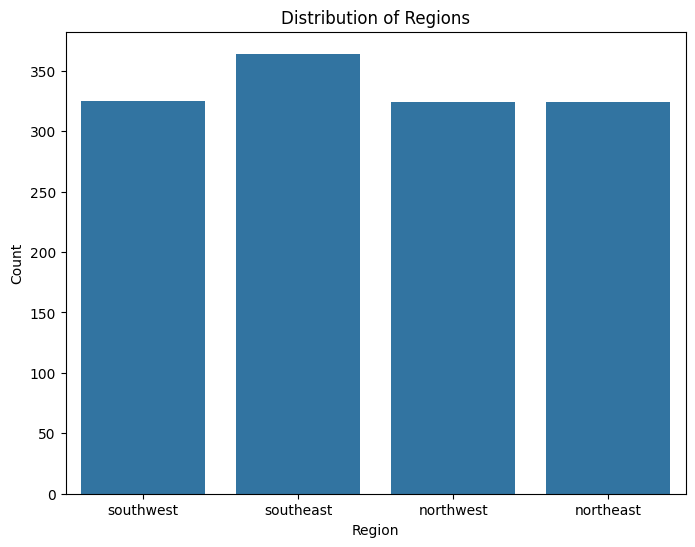

In [ ]:
# Visualize the distribution of regions in the data.
plt.figure(figsize=(8, 6))
sns.countplot(x='region', data=data)
plt.title('Distribution of Regions')
plt.xlabel('Region')
plt.ylabel('Count')
plt.show()


**Observations:**
Most people have a BMI close to 30, with a few high BMI outliers above 45.

>**Visualize the distribution of insurance charges using a box plot.**


**NOTE** : We specifically mention a box plot in the prompt to analyze charges, as it effectively displays the spread, highlights the median, and reveals skewness and outliers.

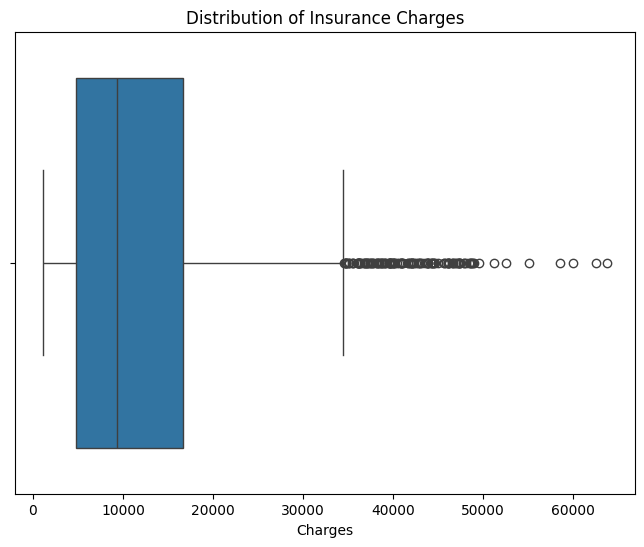

In [ ]:
plt.figure(figsize=(8, 6))
sns.boxplot(x='charges', data=data)
plt.title('Distribution of Insurance Charges')
plt.xlabel('Charges')
plt.show()


**Observations:**


- Most insurance charges are **below 20,000**.
- The **median insurance charge is around 9,000**.
- There are **some outliers above 35,000**.
- These outliers represent customers with **very high insurance charges**.
- The data is **right-skewed**, meaning only a few customers have very high charges.


## **Bivariate Analysis**

 **Bivariate Analysis studies the relationship between two variables.**

**Visualize how insurance charges vary with age.**


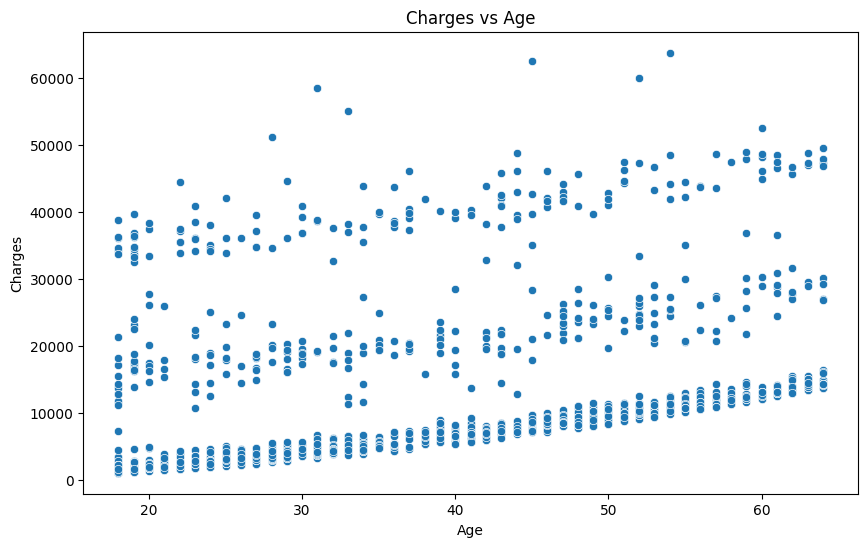

In [ ]:
# Create a scatter plot to visualize the relationship between age and charges.
plt.figure(figsize=(10, 6))
sns.scatterplot(x='age', y='charges', data=data)
plt.title('Charges vs Age')
plt.xlabel('Age')
plt.ylabel('Charges')
plt.show()


**Observations:**
- Insurance charges generally rise with age, indicating a positive correlation where older individuals tend to incur higher costs.
- The chart suggests the presence of three distinct clusters, possibly indicating different insurance plan

**Visualize how insurance charges vary with Smokers.**

</font>

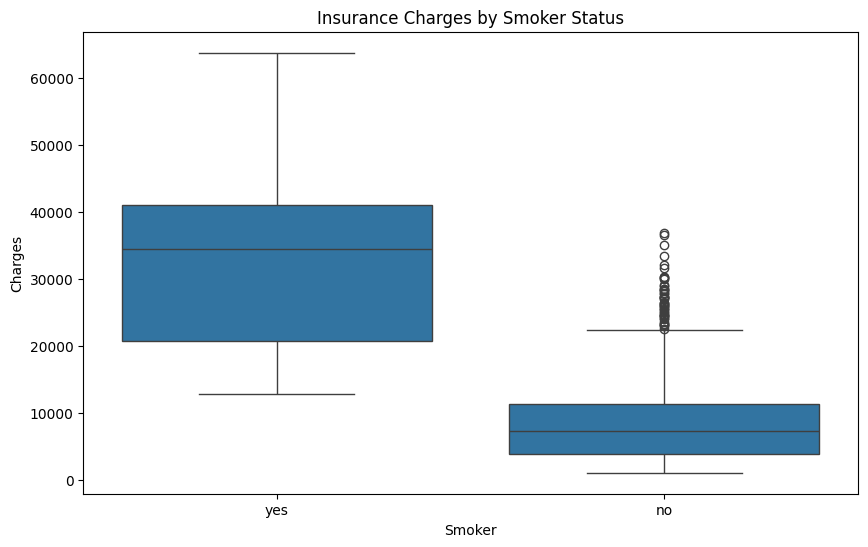

In [ ]:
# Compare charges for smokers vs. non-smokers
plt.figure(figsize=(10, 6))
sns.boxplot(x='smoker', y='charges', data=data)
plt.title('Insurance Charges by Smoker Status')
plt.xlabel('Smoker')
plt.ylabel('Charges')
plt.show()


**Observations:**
- The boxplot reveals a **significant difference in insurance charges between smokers and non-smokers**.
- Smokers tend to incur **much higher medical charges**, with a median above 30,000, compared to non-smokers whose median is below 10,000.
- Additionally, the **spread of charges is much wider** for smokers, indicating more variability and higher risk.
- This strong contrast suggests that smoking status is a **critical factor** in determining insurance pricing.

**Visualize how insurance charges vary with Gender.**

</font>

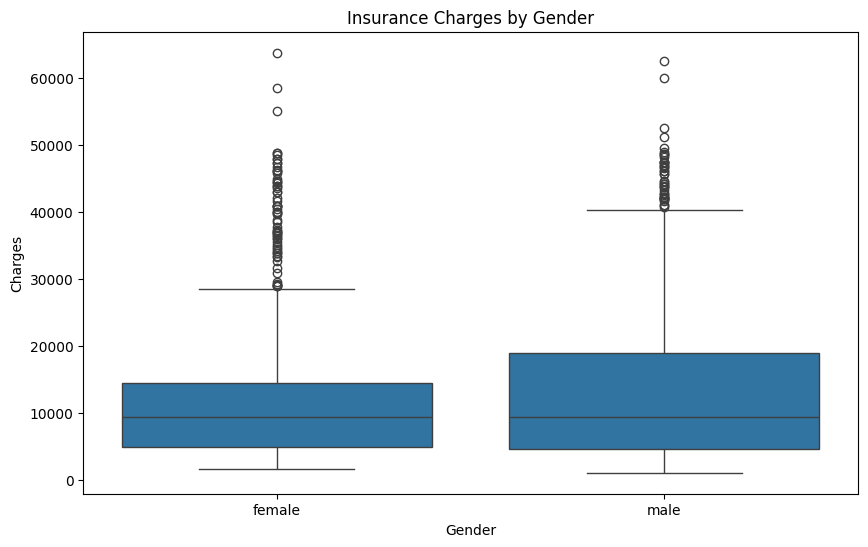

In [ ]:
# Analyze if gender affects charges.
plt.figure(figsize=(10, 6))
sns.boxplot(x='sex', y='charges', data=data)
plt.title('Insurance Charges by Gender')
plt.xlabel('Gender')
plt.ylabel('Charges')
plt.show()


**Observations:**
- The box plot shows that males generally face higher and more variable insurance charges than females, suggesting gender may influence insurance pricing.
- This also prompts further investigation into whether other factors like **smoking status** or **BMI** are disproportionately associated with gender, which could be indirectly influencing the observed differences.

**Visualize insurance charges across genders (male vs. female), further distinguishing between smokers and non-smokers within each gender using an appropriate chart.**

</font>

Compare charges across sex (male and female) and differentiate between smokers and non-smokers within each gender.

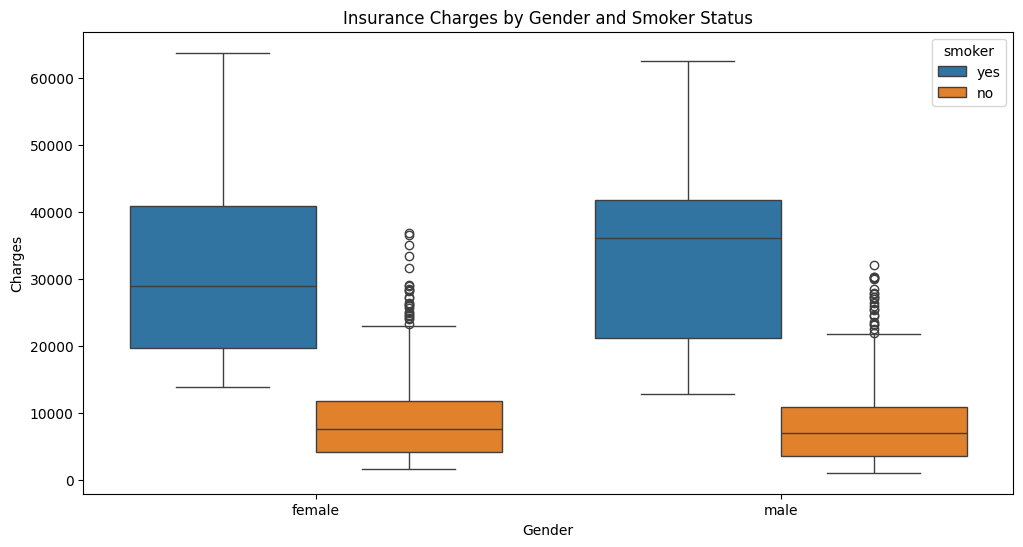

In [ ]:
plt.figure(figsize=(12, 6))
sns.boxplot(x='sex', y='charges', hue='smoker', data=data)
plt.title('Insurance Charges by Gender and Smoker Status')
plt.xlabel('Gender')
plt.ylabel('Charges')
plt.show()


**Observations:**
- **Smokers** (both male and female) clearly have **significantly higher insurance charges** compared to non-smokers.
- Among **smokers**, **males** tend to have **slightly higher median charges** than females.
- For **non-smokers**, the distribution is similar across genders, but **male non-smokers show slightly more variability** in charges.


**Visualize relationships between numerical features (age, BMI, charges) using a pair plot, with 'smoker' as the hue to observe the influence of smoking status.**


</font>

**Observation**

- The pair plot shows the relationship between the numerical features.
- Smoking status has a strong impact on insurance charges.
- **Smokers have much higher insurance charges than non-smokers.**
- There is a clear gap between smokers and non-smokers.
- This indicates that **smoking is an important factor in predicting insurance charges.**



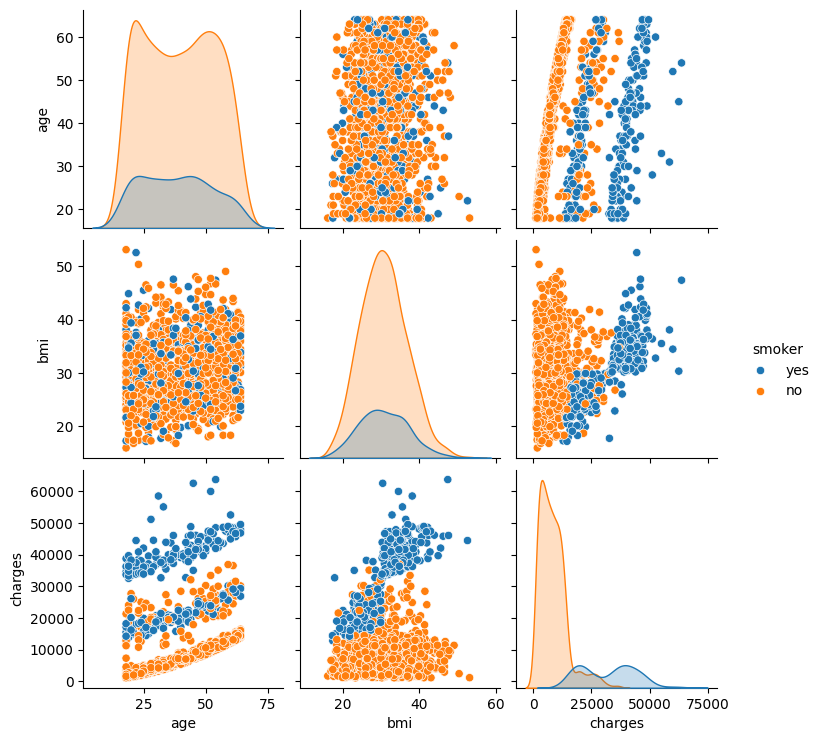

In [ ]:
# Create the pair plot
sns.pairplot(data, vars=['age', 'bmi', 'charges'], hue='smoker')
plt.show()


**Observation:**

- **Smokers** have much **higher insurance charges** than non-smokers.
- **Insurance charges increase as BMI increases**, especially for smokers.
- **Insurance charges increase with age**.
- **Age and BMI distributions are similar** for both smokers and non-smokers.
- **Smoking status has the greatest impact** on insurance charges.





**Visualize how insurance charges vary with No of Childrens.**
</font>

Examine if having more children increases insurance charges.

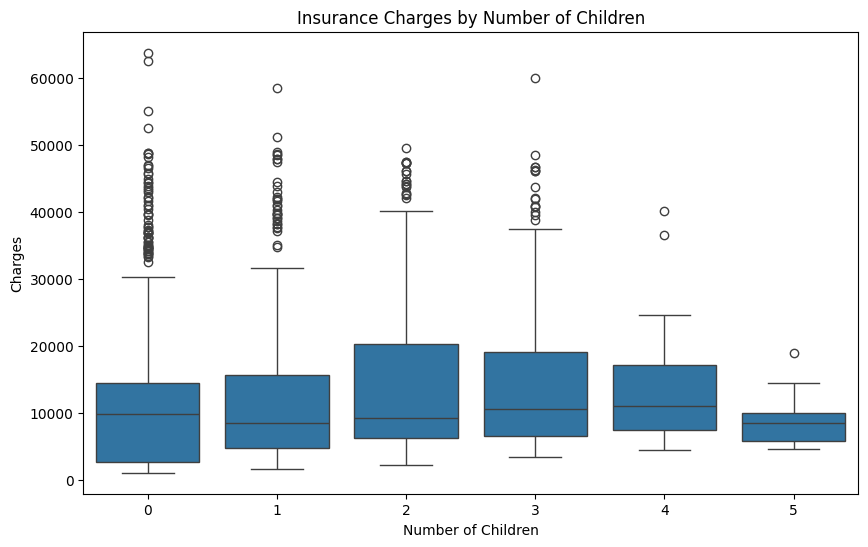

In [ ]:
# Analyze if the number of children influences charges.
plt.figure(figsize=(10, 6))
sns.boxplot(x='children', y='charges', data=data)
plt.title('Insurance Charges by Number of Children')
plt.xlabel('Number of Children')
plt.ylabel('Charges')
plt.show()


**Observations:**
- The box plot suggests that insurance charges increase with one or two children but plateau with three or more, indicating a limited impact of family size beyond a certain point.

**Visualize how insurance charges vary with regions.**
</font>

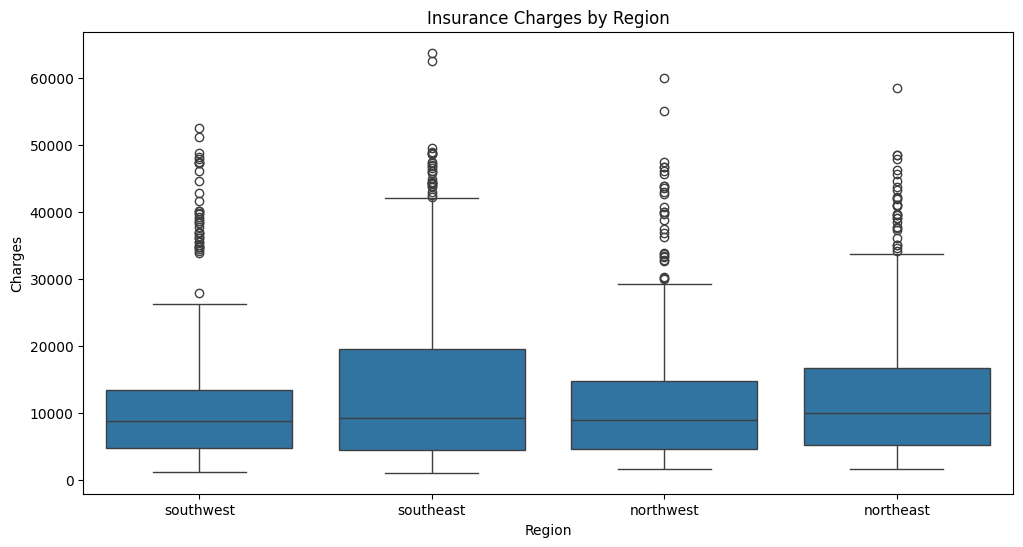

In [ ]:
# Analyze regional differences in charges.
plt.figure(figsize=(12, 6))
sns.boxplot(x='region', y='charges', data=data)
plt.title('Insurance Charges by Region')
plt.xlabel('Region')
plt.ylabel('Charges')
plt.show()



**Observation**

- Insurance charges increase for customers with **1 or 2 children**.
- After **3 or more children**, the charges remain almost the same.
- The number of children has **less impact** on insurance charges compared to age, BMI, and smoking status.
- Family size has only a **small effect** on insurance charges.



**Visualize the numerical columns using a heatmap.**

</font>

## Correlation Heatmap

**Definition:**

> **A correlation heatmap shows the relationship between numerical variables using correlation values.**

**Correlation Values**

- **+1** → Perfect positive correlation (both variables increase together).
- **0** → No correlation (no relationship).
- **-1** → Perfect negative correlation (one variable increases while the other decreases).

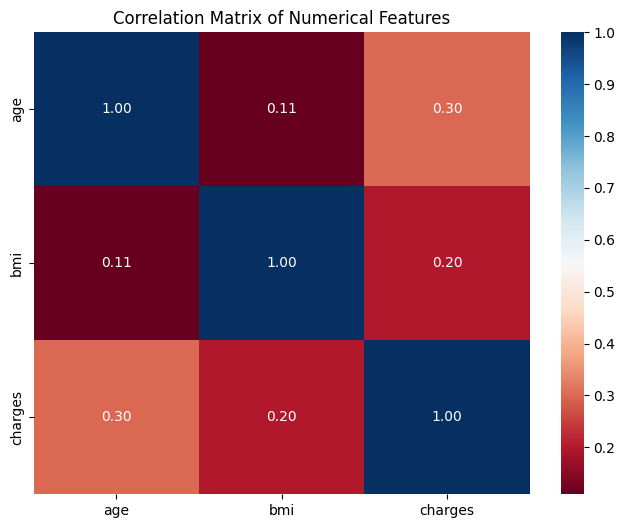

In [ ]:
# Create a correlation matrix for numerical features
numerical_cols = ['age', 'bmi', 'charges']
correlation_matrix = data[numerical_cols].corr()

# Create the heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='RdBu', fmt=".2f")
plt.title('Correlation Matrix of Numerical Features')
plt.show()


**Observatios:**

- **Age vs Charges (0.30)**:  
   There’s a **moderate positive correlation**. This means that as people get older, their insurance charges tend to increase.

- **BMI vs Charges (0.20)**:  
   There’s a **weak positive correlation**. Higher BMI might lead to higher insurance charges, but the relationship isn't very strong.

- **Age vs BMI (0.11)**:  
   Almost **no correlation** — a person’s age doesn't really tell us much about their BMI.


# **Data Preprocessing**

Model 1 – Simple Linear Regression

- Use only **Age** as the input feature.
- Predict **Insurance Charges**.

Model 2 – Multiple Linear Regression

- Use **Age** and **BMI** as input features.
- Predict **Insurance Charges**.

 Model 3 – Multiple Linear Regression (All Features)

- Use **all available features**.
- Numerical features: **Age, BMI, Children**
- Categorical features: **Sex, Smoker, Region**

**Encoding Categorical Variables**

- Machine Learning models accept only **numerical data**.
- Convert categorical features into numbers using **One-Hot Encoding** or **Dummy Encoding**.

**Train-Test Split**

- Split the dataset into **Training** and **Testing** data.
- **80%** of the data is used for training.
- **20%** of the data is used for testing.

**Purpose**

- Build different regression models.
- Compare their performance.
- Select the model with the best prediction accuracy.




**Dummy encode the 'sex', 'smoker', and 'region' columns in the data using dtype=int**
</font>

**NOTE :** We use **dtype=int** in dummy encoding to guarantee that the output is numerical (0 and 1), as it may otherwise default to Boolean values (True and False).

In [ ]:
data = pd.get_dummies(data, columns=['sex', 'smoker', 'region'], drop_first=True, dtype=int)


We check the DataFrame to verify whether the data has been encoded correctly.

**Show the first 10 rows of the data.**


</font>

In [ ]:
data.head(10)

,age,bmi,children,charges,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest
0,19,27.900,0,16884.92400,0,1,0,0,1
1,18,33.770,1,1725.55230,1,0,0,1,0
2,28,33.000,3,4449.46200,1,0,0,1,0
3,33,22.705,0,21984.47061,1,0,1,0,0
4,32,28.880,0,3866.85520,1,0,1,0,0
5,31,25.740,0,3756.62160,0,0,0,1,0
6,46,33.440,1,8240.58960,0,0,0,1,0
7,37,27.740,3,7281.50560,0,0,1,0,0
8,37,29.830,2,6406.41070,1,0,0,0,0
9,60,25.840,0,28923.13692,0,0,1,0,0


### Train Test Split

**Train-Test Split is the process of dividing the dataset into training and testing data.**


***Prompt***:

<font size=3 color="navyblue">Split the data into training and testing sets, using `Charges` as the dependent variable (`y`). Use 70% of the data for training and 30% for testing.


</font>

In [ ]:
# Split data into features (X) and target (y)
X = data.drop('charges', axis=1)
y = data['charges']




In [ ]:
# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

***Prompt***:

<font size=3 color="navyblue">Check the shape of the training and testing data.
</font>

In [ ]:
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)


X_train shape: (935, 8)
X_test shape: (402, 8)
y_train shape: (935,)
y_test shape: (402,)


The training and testing datasets are properly split, with approximately 70% of the data used for training and 30% for testing.

# **Model Building**


After training the model, we evaluate its performance using **R² Score** and **MSE**.

**Possible Errors :**

- **Underestimation** – Predicted insurance charge is **lower** than the actual charge.
- **Overestimation** – Predicted insurance charge is **higher** than the actual charge.

> **Note:** Underestimation is more risky because the insurance company may charge less and lose money.

**Evaluation Metrics :**

- **Maximize R² Score** → Higher R² means better model performance.
- **Minimize MSE** → Lower MSE means fewer prediction errors.

**Purpose**

- Check the accuracy of the model.
- Reduce prediction errors.
- Select the best model.



**Linear Regression Model Training**


**Model Training**

- Train the model using the **training dataset**.
- The model learns the relationship between the input features and insurance charges.
- After training, the model predicts insurance charges for new data.

**Store Results**

- Create a **blank DataFrame**.
- Store the **training** and **testing** results of each model.
- Compare the performance of different models.




**Create a blank DataFrame named model_eval_results to store the performance results of different models on the training and testing sets.**
</font>

In [ ]:
# prompt: Create a blank DataFrame named model_eval_results to store the performance results of different models on the training and testing sets.

model_eval_results = pd.DataFrame(columns=['Model', 'Train_MSE', 'Train_R2', 'Test_MSE', 'Test_R2'])

### **Model 1**

In the first model, we use only the `age` feature to demonstrate how simple linear regression works and how it performs.

**Train a linear regression model using age as feature and charges as the dependent column.**

</font>

In [ ]:
# Define features (X) and target (y) for Model 1 (Age only)
X_train_m1 = X_train[['age']]
X_test_m1 = X_test[['age']]

# Initialize and train the Linear Regression model
model_1 = LinearRegression()
model_1.fit(X_train_m1, y_train)

LinearRegression()


**Display the linear regression equation.**

</font>

In [ ]:
print(f'Linear Regression Equation: Charges = {model_1.intercept_:.2f} + ({model_1.coef_[0]:.2f} * Age)')

Linear Regression Equation: Charges = 3718.81 + (238.82 * Age)


## Model Evaluation

- Insurance charges **increase as age increases**.
- Evaluate the model using **R² Score** and **MSE**.
- **Higher R²** indicates better model performance.
- **Lower MSE** indicates fewer prediction errors.
- Compare the results to check how well the model predicts insurance charges.



**Evaluate the model’s performance on both the training and testing data, add it to model_eval_results, and display the results.**


</font>

**Predict Values**

In [ ]:
# Predict on training data
y_train_pred_m1 = model_1.predict(X_train_m1)

# Predict on testing data
y_test_pred_m1 = model_1.predict(X_test_m1)

**Calculate Training Metrics**

In [ ]:
# Calculate MSE and R2 for training data
train_mse_m1 = mean_squared_error(y_train, y_train_pred_m1)
train_r2_m1 = r2_score(y_train, y_train_pred_m1)


**Calculate Testing Metrics**

In [ ]:
# Calculate MSE and R2 for testing data
test_mse_m1 = mean_squared_error(y_test, y_test_pred_m1)
test_r2_m1 = r2_score(y_test, y_test_pred_m1)

**Store Results**

In [ ]:
# Add results to the DataFrame
model_eval_results.loc[len(model_eval_results)] = ['Model 1 (Age Only)', train_mse_m1, train_r2_m1, test_mse_m1, test_r2_m1]

**Display Results**

In [ ]:

# Display the results
model_eval_results

,Model,Train_MSE,Train_R2,Test_MSE,Test_R2
0,Model 1 (Age Only),1.246248e+08,0.082229,1.545219e+08,0.096985


**Linear Regression Analysis using Statsmodels**

In [ ]:
!pip install ISLP

In [ ]:

import statsmodels.api as sm
from ISLP.models import ModelSpec as MS

# Select predictor 'age' from the insurance dataset
terms = MS(['age'])

X_design_train = terms.fit_transform(X_train)
model_ols = sm.OLS(y_train, X_design_train)

# Train the model
results_ols = model_ols.fit()
print(results_ols.summary())

                            OLS Regression Results                            
Dep. Variable:                charges   R-squared:                       0.082
Model:                            OLS   Adj. R-squared:                  0.081
Method:                 Least Squares   F-statistic:                     83.59
Date:                Wed, 15 Jul 2026   Prob (F-statistic):           3.71e-19
Time:                        00:59:49   Log-Likelihood:                -10041.
No. Observations:                 935   AIC:                         2.009e+04
Df Residuals:                     933   BIC:                         2.010e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
intercept   3718.8108   1082.518      3.435      0.0

- The error is high and the R-squared value is low for both the training and testing datasets, indicating poor model performance and underfitting.
- This is likely due to the use of only a single feature and a simple linear model.

### Model 2

In the second model, we use only the numerical features to train a multiple linear regression model, and evaluate how well the model performs.

**Train a linear regression model using age and BMI as features, and charges as the dependent column.**

</font>

In [ ]:
# Define features (X) and target (y) for Model 2 (Age and BMI)
X_train_m2 = X_train[['age', 'bmi']]
X_test_m2 = X_test[['age', 'bmi']]

# Initialize and train the Linear Regression model
model_2 = LinearRegression()
model_2.fit(X_train_m2, y_train)

LinearRegression()

**Display the linear regression equation.**

</font>

In [ ]:
print(f'Linear Regression Equation: Charges = {model_2.intercept_:.2f} + ({model_2.coef_[0]:.2f} * Age) + ({model_2.coef_[1]:.2f} * BMI)')


Linear Regression Equation: Charges = -3641.79 + (227.40 * Age) + (254.94 * BMI)


## Model Evaluation

- Insurance charges **increase as BMI increases** (when age is constant).
- Evaluate the model using **R² Score** and **MSE**.
- **Higher R²** means the model predicts better.
- **Lower MSE** means fewer prediction errors.
- Compare the training and testing results to check model performance.



**Evaluate the model’s performance on both the training and testing data, add it to model_eval_results, and display the results.**


</font>

**Predict Values**

In [ ]:
# Predict on training and testing data
y_train_pred_m2 = model_2.predict(X_train_m2)
y_test_pred_m2 = model_2.predict(X_test_m2)

**Calculate Training Metrics**

In [ ]:
# Calculate MSE and R2 for training data
train_mse_m2 = mean_squared_error(y_train, y_train_pred_m2)
train_r2_m2 = r2_score(y_train, y_train_pred_m2)

**Calculate Testing Metrics**

In [ ]:
# Calculate MSE and R2 for testing data
test_mse_m2 = mean_squared_error(y_test, y_test_pred_m2)
test_r2_m2 = r2_score(y_test, y_test_pred_m2)


**Store Results**

In [ ]:
# Add results to the DataFrame
model_eval_results.loc[len(model_eval_results)] = ['Model 2 (Age and BMI)', train_mse_m2, train_r2_m2, test_mse_m2, test_r2_m2]

**Display Results**

In [ ]:
# Display the results
model_eval_results

,Model,Train_MSE,Train_R2,Test_MSE,Test_R2
0,Model 1 (Age Only),1.246248e+08,0.082229,1.545219e+08,0.096985
1,Model 2 (Age and BMI),1.222942e+08,0.099392,1.471034e+08,0.140338


- The error has reduced slightly, but is still high, and the R-squared value is low for both the training and testing data, indicating that the model is still performing poorly and **underfitting**.


**Linear Regression Analysis using Statsmodels**

In [ ]:
import statsmodels.api as sm
from ISLP.models import ModelSpec as MS

# Select predictor 'age' from the insurance dataset
terms = MS(['age','bmi'])

X_design_train = terms.fit_transform(X_train)
model_ols = sm.OLS(y_train, X_design_train)

# Train the model
results_ols = model_ols.fit()
print(results_ols.summary())

                            OLS Regression Results                            
Dep. Variable:                charges   R-squared:                       0.099
Model:                            OLS   Adj. R-squared:                  0.097
Method:                 Least Squares   F-statistic:                     51.43
Date:                Wed, 15 Jul 2026   Prob (F-statistic):           6.51e-22
Time:                        01:00:14   Log-Likelihood:                -10032.
No. Observations:                 935   AIC:                         2.007e+04
Df Residuals:                     932   BIC:                         2.009e+04
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
intercept  -3641.7938   2049.775     -1.777      0.0

### Model 3

**all features to build a more accurate Linear Regression model and compare its performance with other models.**

**Train a linear regression model using all features, and charges as the dependent column.**


</font>

In [ ]:
# Initialize and train the Linear Regression model on the whole data
model_3 = LinearRegression()
model_3.fit(X_train, y_train)

LinearRegression()

**Display the linear regression equation.**

</font>

In [ ]:
# Construct the equation string
equation = f'Charges = {model_3.intercept_:.2f}'
for i, col in enumerate(X_train.columns):
    equation += f' + ({model_3.coef_[i]:.2f} * {col})'

print(f'Linear Regression Equation: {equation}')

Linear Regression Equation: Charges = -11516.78 + (251.25 * age) + (328.38 * bmi) + (522.16 * children) + (-111.91 * sex_male) + (22874.45 * smoker_yes) + (-465.75 * region_northwest) + (-936.10 * region_southeast) + (-765.58 * region_southwest)


# **Model Evaluation**

**Evaluate the model’s performance on both the training and testing data, add it to model_eval_results, and display the results.**

</font>

**Predict Model**

In [ ]:
# prompt: Evaluate the model’s performance on both the training and testing data, add it to model_eval_results, and display the results.

# Predict on training and testing data
y_train_pred_m3 = model_3.predict(X_train)
y_test_pred_m3 = model_3.predict(X_test)



**Training Data**

In [ ]:
# Calculate MSE and R2 for training data
train_mse_m3 = mean_squared_error(y_train, y_train_pred_m3)
train_r2_m3 = r2_score(y_train, y_train_pred_m3)




**Testing Data**

In [ ]:
# Calculate MSE and R2 for testing data
test_mse_m3 = mean_squared_error(y_test, y_test_pred_m3)
test_r2_m3 = r2_score(y_test, y_test_pred_m3)



**Store as Result**

In [ ]:
# Add results to the DataFrame
model_eval_results.loc[len(model_eval_results)] = ['Model 3 (All Features)', train_mse_m3, train_r2_m3, test_mse_m3, test_r2_m3]

**Display the value**

In [ ]:
# Display the Dataframe
model_eval_results

,Model,Train_MSE,Train_R2,Test_MSE,Test_R2
0,Model 1 (Age Only),1.246248e+08,0.082229,1.545219e+08,0.096985
1,Model 2 (Age and BMI),1.222942e+08,0.099392,1.471034e+08,0.140338
2,Model 3 (All Features),3.581293e+07,0.736264,3.894017e+07,0.772436


**Linear Regression Analysis using Statsmodels**

In [ ]:
import statsmodels.api as sm
from ISLP.models import ModelSpec as MS

# Select all predictor features from the insurance dataset
terms = MS(['age', 'bmi', 'children', 'sex_male', 'smoker_yes', 'region_northwest', 'region_southeast', 'region_southwest'])

X_design_train = terms.fit_transform(X_train)
model_ols = sm.OLS(y_train, X_design_train)

# Train the model
results_ols = model_ols.fit()
print(results_ols.summary())

                            OLS Regression Results                            
Dep. Variable:                charges   R-squared:                       0.736
Model:                            OLS   Adj. R-squared:                  0.734
Method:                 Least Squares   F-statistic:                     323.1
Date:                Wed, 15 Jul 2026   Prob (F-statistic):          6.73e-262
Time:                        01:01:05   Log-Likelihood:                -9458.3
No. Observations:                 935   AIC:                         1.893e+04
Df Residuals:                     926   BIC:                         1.898e+04
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
intercept        -1.152e+04   1189.078  

- The training and testing R-squared values are close (0.736 and 0.772), with MSE values similarly close, indicating the model is generalizing well, **not overfitting**, and performing well on unseen data.

In [ ]:
data_to_predict=X_test.head(8)
res=model_3.predict(data_to_predict)
print(f"predict insurance charge for the new customer:${res[0]:.2f}")

predict insurance charge for the new customer:$8075.92


## **Model Comparison and Final Model Selecttion**

**Show the model evaluation metrics in `model_eval_results`.**

</font>

In [ ]:
model_eval_results

,Model,Train_MSE,Train_R2,Test_MSE,Test_R2
0,Model 1 (Age Only),1.246248e+08,0.082229,1.545219e+08,0.096985
1,Model 2 (Age and BMI),1.222942e+08,0.099392,1.471034e+08,0.140338
2,Model 3 (All Features),3.581293e+07,0.736264,3.894017e+07,0.772436



**Observation**

- **Model 1 (Age)** has the **lowest performance**.
- **Model 2 (Age + BMI)** performs **better than Model 1**.
- **Model 3 (All Features)** has the **highest R²** and **lowest MSE**.
- Model 3 predicts insurance charges **more accurately**.





**Business Recommendations**

- **Adjust Premiums:** Set insurance premiums based on **Age** and **BMI**.
- **Encourage Non-Smoking:** Offer discounts or rewards to **non-smokers**.
- **Promote Healthy Lifestyle:** Introduce wellness programs to help customers maintain a healthy BMI.
- **Regional Pricing:** Use region-based pricing only if there are significant cost differences.
- **Target Low-Risk Customers:** Focus on **young, non-smoking, and healthy BMI** customers with affordable plans.



# **Prediction**

In [ ]:
# Prediction using the Best Model (Model 3)

new_customer_data = {
    'age': 30,
    'bmi': 25.0,
    'children': 2,
    'sex_male': 0,
    'smoker_yes': 0,
    'region_northwest': 0,
    'region_southeast': 1,
    'region_southwest': 0
}

# Convert into DataFrame
new_customer_df = pd.DataFrame([new_customer_data], columns=X_train.columns)

# Predict insurance charge
predicted_charge = model_3.predict(new_customer_df)

print("Predicted Insurance Charge: $", round(predicted_charge[0], 2))

Predicted Insurance Charge: $ 4338.39


# **Best Fit Model**


After comparing the performance of all three models using evaluation metrics such as R² Score, the third model (Multiple Linear Regression with all features) is the best-fit model because it achieves the highest prediction accuracy and explains the maximum variation in insurance charges. Therefore, Model 3 is selected as the final model for predicting health insurance charges

# **Conclusion**



1. Model 3 is the best model.
2. It uses all available features.
3. It gives the most accurate predictions.

<font size=6 color="navyblue">Power Ahead!</font>
___